# 01. EDA - Описательный анализ датасета NFS-2023-nTE

**Цель:** Осмотр датасета NFS-2023-nTE (на основе CIC-IDS-2017). Сборка единого датафрейма, базовая статистика, распределение таргета, классы меток (BENIGN и атаки), привязка к дням, выявление проблем.

**Результаты (сохранения):** 
1) `eda_describe_stats.csv` - `describe()` по числовым признакам
2) `eda_label_distribution.csv` - типы атак по дням
3) `fig_01_*` - графики распределения меток
4) `nfs_2023_nte_all.parquet` - объединенный датафрейм для последующих ноутбуков 

In [34]:
# ------- Импорты -------
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ------- Пути -------
try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()

PROJECT_ROOT = NB_DIR

DATASET_DIR  = PROJECT_ROOT / "NFS-2023-nTE"
RESULTS_DIR  = PROJECT_ROOT / "results"
FIG_DIR      = RESULTS_DIR / "figures"
TAB_DIR      = RESULTS_DIR / "tables"
CACHE_DIR    = PROJECT_ROOT / "cache"
ARTIFACTS    = PROJECT_ROOT / "artifacts"
MODELS_DIR   = PROJECT_ROOT / "models"

for p in (FIG_DIR, TAB_DIR, CACHE_DIR, ARTIFACTS, MODELS_DIR):
    p.mkdir(parents=True, exist_ok=True)

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
LABEL_COL = "label"
BENIGN_LABEL = "BENIGN"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR :", DATASET_DIR, "  exists:", DATASET_DIR.exists())
print("RESULTS_DIR :", RESULTS_DIR)
print("CACHE_DIR   :", CACHE_DIR)


PROJECT_ROOT: /workspace
DATASET_DIR : /workspace/NFS-2023-nTE   exists: True
RESULTS_DIR : /workspace/results
CACHE_DIR   : /workspace/cache


## 1. Обзор файлов датасета

In [35]:
rows = []
for day in DAYS:
    fp = DATASET_DIR / f"{day}.csv"
    rows.append({
        "day": day,
        "path": str(fp),
""        "size_MB": round(fp.stat().st_size / 1024**2, 1) if fp.exists() else None,
    })
inventory = pd.DataFrame(rows)
inventory


,day,path,size_MB
0,Monday,/workspace/NFS-2023-nTE/Monday.csv,154.8
1,Tuesday,/workspace/NFS-2023-nTE/Tuesday.csv,132.8
2,Wednesday,/workspace/NFS-2023-nTE/Wednesday.csv,218.1
3,Thursday,/workspace/NFS-2023-nTE/Thursday.csv,139.9
4,Friday,/workspace/NFS-2023-nTE/Friday.csv,218.0


In [36]:
total_mb = inventory["size_MB"].sum()
print(f"Суммарный размер: {total_mb:.1f} MB.")


Суммарный размер: 863.6 MB.


## 2. Колонки и признаки

In [37]:
schema_df = pd.read_csv(DATASET_DIR / "Monday.csv", nrows=100)
print("Колонок:", len(schema_df.columns))
print("Среди них колонка label:", LABEL_COL in schema_df.columns)
print()
print("dtypes (по 100 строкам):")
print(schema_df.dtypes.to_string())


Колонок: 77
Среди них колонка label: True

dtypes (по 100 строкам):
id                                int64
expiration_id                     int64
src_ip                              str
src_mac                             str
src_oui                             str
src_port                          int64
dst_ip                              str
dst_mac                             str
dst_oui                             str
dst_port                          int64
protocol                          int64
ip_version                        int64
vlan_id                           int64
bidirectional_first_seen_ms       int64
bidirectional_last_seen_ms        int64
bidirectional_duration_ms         int64
bidirectional_packets             int64
bidirectional_bytes               int64
src2dst_first_seen_ms             int64
src2dst_last_seen_ms              int64
src2dst_duration_ms               int64
src2dst_packets                   int64
src2dst_bytes                     int64
dst2src_firs

In [15]:
# Категории колонок (для дальнейшей работы и для понимания структуры).
SCHEMA_COLUMNS = list(schema_df.columns)
IDENTITY_COLS    = ["id", "expiration_id"]
NETWORK_ID_COLS  = ["src_ip", "src_mac", "src_oui", "src_port",
                    "dst_ip", "dst_mac", "dst_oui", "dst_port"]
TIMESTAMP_COLS   = [c for c in SCHEMA_COLUMNS if c.endswith(("_first_seen_ms", "_last_seen_ms"))]
META_COLS        = ["protocol", "ip_version", "vlan_id"]
NUMERIC_COLS     = [c for c in SCHEMA_COLUMNS
                    if c not in IDENTITY_COLS + NETWORK_ID_COLS + [LABEL_COL]
                    and schema_df[c].dtype != object]

print(f"Identity (id/expiration_id): {len(IDENTITY_COLS)}")
print(f"Network identifiers:         {len(NETWORK_ID_COLS)}")
print(f"Absolute timestamps:         {len(TIMESTAMP_COLS)}")
print(f"Meta (protocol/ip_version/vlan): {len(META_COLS)}")
print(f"Numeric (всего, для describe): {len(NUMERIC_COLS)}")
print()
print(f"Все {len(schema_df.columns)} колонок (для справки):")
for i, c in enumerate(SCHEMA_COLUMNS, 1):
    print(f"  {i:>2}. {c}")


Identity (id/expiration_id): 2
Network identifiers:         8
Absolute timestamps:         6
Meta (protocol/ip_version/vlan): 3
Numeric (всего, для describe): 66

Все 77 колонок (для справки):
   1. id
   2. expiration_id
   3. src_ip
   4. src_mac
   5. src_oui
   6. src_port
   7. dst_ip
   8. dst_mac
   9. dst_oui
  10. dst_port
  11. protocol
  12. ip_version
  13. vlan_id
  14. bidirectional_first_seen_ms
  15. bidirectional_last_seen_ms
  16. bidirectional_duration_ms
  17. bidirectional_packets
  18. bidirectional_bytes
  19. src2dst_first_seen_ms
  20. src2dst_last_seen_ms
  21. src2dst_duration_ms
  22. src2dst_packets
  23. src2dst_bytes
  24. dst2src_first_seen_ms
  25. dst2src_last_seen_ms
  26. dst2src_duration_ms
  27. dst2src_packets
  28. dst2src_bytes
  29. bidirectional_min_ps
  30. bidirectional_mean_ps
  31. bidirectional_stddev_ps
  32. bidirectional_max_ps
  33. src2dst_min_ps
  34. src2dst_mean_ps
  35. src2dst_stddev_ps
  36. src2dst_max_ps
  37. dst2src_min_ps


## 3. Оптимизация dtypes (типов признаков) для загрузки

Суммарно все 5 CSV весят - 864 МБ. В памяти загрузка датасета, будет занимать ~4 ГБ.

Чтобы EDA выполнялся проще, и модели обработка датасета происходила чуть быстрее - снижается разрядность некоторых признаков.

- Счетчики пакетов и флагов: они ограничены, и легко заменяются на тип `int32`
- Флаги вообще можно заменить в `int16/uint16`

In [16]:
DTYPE_HINTS: dict[str, str] = {}

# 1) флаги (значения пакетов с конкретным флагом) >> int32
for c in SCHEMA_COLUMNS:
    if c.endswith(("_syn_packets", "_cwr_packets", "_ece_packets",
                   "_urg_packets", "_ack_packets", "_psh_packets",
                   "_rst_packets", "_fin_packets")):
        DTYPE_HINTS[c] = "int32"

# 2) счетчики пакетов и протокольные числа >> int32
for c in ("protocol", "ip_version", "vlan_id",
          "bidirectional_packets", "src2dst_packets", "dst2src_packets"):
    DTYPE_HINTS[c] = "int32"

# 3) packet-size: min/max >> int32, 
#    mean/stddev >> float32
for c in SCHEMA_COLUMNS:
    if c.endswith(("_min_ps", "_max_ps")):
        DTYPE_HINTS[c] = "int32"
    elif c.endswith(("_mean_ps", "_stddev_ps")):
        DTYPE_HINTS[c] = "float32"

# 4) piat: 
#    min/max — int32, mean/stddev >> float32
for c in SCHEMA_COLUMNS:
    if c.endswith(("_min_piat_ms", "_max_piat_ms")):
        DTYPE_HINTS[c] = "int32"
    elif c.endswith(("_mean_piat_ms", "_stddev_piat_ms")):
        DTYPE_HINTS[c] = "float32"

# 5) id / expiration_id, src/dst port >> int32
for c in ("id", "expiration_id", "src_port", "dst_port"):
    DTYPE_HINTS[c] = "int32"

# строки >> category, чтобы экономить память
for c in ("src_ip", "dst_ip", "src_mac", "dst_mac",
         "src_oui", "dst_oui", LABEL_COL):
    DTYPE_HINTS[c] = "category"

print(f"Подсказок dtype: {len(DTYPE_HINTS)}")


Подсказок dtype: 65


## 4. Загрузка всех 5 CSV

- Грузятся по очереди дни, добавляется колонка `day` (это полезно для будующего анализа), затем дни объединяются.

- Пишется общий датасет в формат `parquet`, снова проводить парсинг CSV - не требуется

- Если `parquet` (созданный) есть в `cache` - то он переиспользуется.

In [18]:
CACHE_PARQUET = CACHE_DIR / "nfs_2023_nte_all.parquet"

if CACHE_PARQUET.exists():
    print(f"Cache Found: {CACHE_PARQUET}")
    print("Loading parquet")
    df_all = pd.read_parquet(CACHE_PARQUET)
else:
    print("Cache not found reading")
    frames = []
    for day in DAYS:
        fp = DATASET_DIR / f"{day}.csv"
        print(f"  -- reading: {fp.name} ...", end=" ", flush=True)
        df_day = pd.read_csv(fp, dtype=DTYPE_HINTS, low_memory=False)
        df_day["day"] = pd.Categorical(
            [day] * len(df_day), categories=DAYS, ordered=True
        )
        print(f"shape={df_day.shape}")
        frames.append(df_day)
    df_all = pd.concat(frames, axis=0, ignore_index=True)
    del frames
    print(f"\nConcat: shape={df_all.shape}")
    print(f"Saving to {CACHE_PARQUET} ...")
    df_all.to_parquet(CACHE_PARQUET, index=False)

print(f"\nTotal: {df_all.shape[0]:,} строк, {df_all.shape[1]} колонок")
print(f"Memory: {df_all.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Cache not found reading
  -- reading: Monday.csv ... shape=(376826, 78)
  -- reading: Tuesday.csv ... shape=(325677, 78)
  -- reading: Wednesday.csv ... shape=(503140, 78)
  -- reading: Thursday.csv ... shape=(358302, 78)
  -- reading: Friday.csv ... shape=(547186, 78)

Concat: shape=(2111131, 78)
Saving to /workspace/cache/nfs_2023_nte_all.parquet ...

Total: 2,111,131 строк, 78 колонок
Memory: 780.8 MB


## 5. Базовый осмотр объединненого/собранного датасета

In [19]:
print("=== shape ===")
print(df_all.shape)

print("\n=== строк по дням ===")
print(df_all["day"].value_counts(sort=False).to_string())

print("\n=== dtypes по группам ===")
print(df_all.dtypes.value_counts().to_string())


=== shape ===
(2111131, 78)

=== строк по дням ===
day
Monday       376826
Tuesday      325677
Wednesday    503140
Thursday     358302
Friday       547186

=== dtypes по группам ===
int32       46
int64       12
float32     12
str          3
category     1
category     1
category     1
category     1
category     1


In [20]:
df_all.head(3)

,id,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,ip_version,vlan_id,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_first_seen_ms,dst2src_last_seen_ms,dst2src_duration_ms,dst2src_packets,dst2src_bytes,bidirectional_min_ps,bidirectional_mean_ps,bidirectional_stddev_ps,bidirectional_max_ps,src2dst_min_ps,src2dst_mean_ps,src2dst_stddev_ps,src2dst_max_ps,dst2src_min_ps,dst2src_mean_ps,dst2src_stddev_ps,dst2src_max_ps,bidirectional_min_piat_ms,bidirectional_mean_piat_ms,bidirectional_stddev_piat_ms,bidirectional_max_piat_ms,src2dst_min_piat_ms,src2dst_mean_piat_ms,src2dst_stddev_piat_ms,src2dst_max_piat_ms,dst2src_min_piat_ms,dst2src_mean_piat_ms,dst2src_stddev_piat_ms,dst2src_max_piat_ms,bidirectional_syn_packets,bidirectional_cwr_packets,bidirectional_ece_packets,bidirectional_urg_packets,bidirectional_ack_packets,bidirectional_psh_packets,bidirectional_rst_packets,bidirectional_fin_packets,src2dst_syn_packets,src2dst_cwr_packets,src2dst_ece_packets,src2dst_urg_packets,src2dst_ack_packets,src2dst_psh_packets,src2dst_rst_packets,src2dst_fin_packets,dst2src_syn_packets,dst2src_cwr_packets,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,label,day
0,2,0,192.168.10.9,b8:ac:6f:1d:1f:6c,b8:ac:6f,60372,224.0.0.252,01:00:5e:00:00:fc,01:00:5e,5355,17,4,0,1499082997568,1499082997667,99,2,140,1499082997568,1499082997667,99,2,140,0,0,0,0,0,70,70.0,0.0,70,70,70.0,0.0,70,0,0.0,0.0,0,99,99.000000,0.000000,99,99,99.0,0.0,99,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BENIGN,Monday
1,3,0,192.168.10.9,b8:ac:6f:1d:1f:6c,b8:ac:6f,123,192.168.10.3,18:66:da:9b:e3:7d,18:66:da,123,17,4,0,1499083015428,1499083016935,1507,4,360,1499083015428,1499083016934,1506,2,180,1499083015429,1499083016935,1506,2,180,90,90.0,0.0,90,90,90.0,0.0,90,90,90.0,0.0,90,1,502.333344,868.334778,1505,1506,1506.0,0.0,1506,1506,1506.0,0.0,1506,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BENIGN,Monday
2,4,0,192.168.10.12,b8:ac:6f:36:04:e3,b8:ac:6f,123,192.168.10.3,18:66:da:9b:e3:7d,18:66:da,123,17,4,0,1499083050571,1499083051568,997,4,360,1499083050571,1499083051568,997,2,180,1499083050571,1499083051568,997,2,180,90,90.0,0.0,90,90,90.0,0.0,90,90,90.0,0.0,90,0,332.333344,575.618225,997,997,997.0,0.0,997,997,997.0,0.0,997,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BENIGN,Monday


In [21]:
# describe только по числовым колонкам
numeric_cols_all = df_all.select_dtypes(include=[np.number]).columns.tolist()
desc = df_all[numeric_cols_all].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

# округление для читаемости
desc_rounded = desc.copy()
for c in desc_rounded.columns:
    desc_rounded[c] = desc_rounded[c].astype(float).round(3)

desc_rounded.to_csv(TAB_DIR / "eda_descriptive_stats.csv")
print(f"Сохранено: {TAB_DIR / 'eda_descriptive_stats.csv'}")
print(f"Строк (колонок-чисел): {len(desc_rounded)}")
desc_rounded.head(15)


Сохранено: /workspace/results/tables/eda_descriptive_stats.csv
Строк (колонок-чисел): 70


,count,mean,std,min,1%,5%,50%,95%,99%,max
id,2111131.0,2.208059e+05,1.372344e+05,0.000000e+00,4.236000e+03,2.117900e+04,2.120680e+05,4.733240e+05,5.266787e+05,5.478150e+05
expiration_id,2111131.0,2.600000e-02,1.580000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
src_port,2111131.0,4.831392e+04,1.628735e+04,1.000000e+00,1.230000e+02,6.296000e+03,5.351000e+04,6.311900e+04,6.503200e+04,6.553500e+04
dst_port,2111131.0,1.390939e+03,6.479480e+03,1.000000e+00,5.300000e+01,5.300000e+01,8.000000e+01,5.802000e+03,4.909600e+04,6.553100e+04
protocol,2111131.0,1.133000e+01,5.497000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,1.700000e+01,1.700000e+01,1.700000e+01
ip_version,2111131.0,4.000000e+00,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
vlan_id,2111131.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
bidirectional_first_seen_ms,2111131.0,1.499286e+12,1.256712e+08,1.499083e+12,1.499085e+12,1.499089e+12,1.499272e+12,1.499454e+12,1.499455e+12,1.499458e+12
bidirectional_last_seen_ms,2111131.0,1.499286e+12,1.256697e+08,1.499083e+12,1.499085e+12,1.499089e+12,1.499272e+12,1.499454e+12,1.499455e+12,1.499458e+12
bidirectional_duration_ms,2111131.0,1.092250e+04,2.927494e+04,0.000000e+00,0.000000e+00,0.000000e+00,6.100000e+01,1.151695e+05,1.180190e+05,1.199990e+05


## 6. Проверка колонок на ошибки - NaN, Inf, отрицательные

Для каждой числовой колонки считаются:
- `n_nan` - число пропусков
- `n_inf` - число inf
- `n_negative` - число отрицательных значений

In [22]:
def is_nonneg_by_meaning(col: str) -> bool:
    # True для колонок, которые по смыслу неотрицательны (счетчики,длительности,размеры)
    if col in ("id", "expiration_id", "protocol", "ip_version", "vlan_id",
               "src_port", "dst_port"):
        return False
    if "duration_ms" in col or "_seen_ms" in col:
        return True
    if col.endswith("_packets") or col.endswith("_bytes"):
        return True
    if "_ps" in col or "_piat_ms" in col:
        return True
    return False

health_rows = []
for c in numeric_cols_all:
    s = df_all[c]
    n_nan = int(s.isna().sum())
    n_inf = int(np.isinf(s.to_numpy(dtype="float64", na_value=0.0)).sum())
    n_neg = int((s < 0).sum()) if is_nonneg_by_meaning(c) else None
    health_rows.append({
        "column": c,
        "dtype": str(s.dtype),
        "n_nan": n_nan,
        "pct_nan": round(100 * n_nan / len(s), 4),
        "n_inf": n_inf,
        "n_negative_where_should_be_nonneg": n_neg,
        "min": float(s.min()) if not s.isna().all() else None,
        "max": float(s.max()) if not s.isna().all() else None,
    })

health = pd.DataFrame(health_rows).sort_values(
    ["n_nan", "n_inf"], ascending=False
).reset_index(drop=True)
health.to_csv(TAB_DIR / "eda_column_health.csv", index=False)

# Сразу показываем сводку по проблемам
total_problems = (
    int(health["n_nan"].sum())
    + int(health["n_inf"].sum())
    + int(health["n_negative_where_should_be_nonneg"].fillna(0).sum())
)
print(f"Колонок с NaN: {(health['n_nan'] > 0).sum()}")
print(f"Колонок с Inf: {(health['n_inf'] > 0).sum()}")
print(f"Колонок с неожиданными отрицательными: "
      f"{(health['n_negative_where_should_be_nonneg'].fillna(0) > 0).sum()}")
print(f"Сохранено: {TAB_DIR / 'eda_column_health.csv'}")
health.head(15)


Колонок с NaN: 0
Колонок с Inf: 0
Колонок с неожиданными отрицательными: 0
Сохранено: /workspace/results/tables/eda_column_health.csv


,column,dtype,n_nan,pct_nan,n_inf,n_negative_where_should_be_nonneg,min,max
0,id,int32,0,0.0,0,NaN,0.000000e+00,5.478150e+05
1,expiration_id,int32,0,0.0,0,NaN,0.000000e+00,1.000000e+00
2,src_port,int32,0,0.0,0,NaN,1.000000e+00,6.553500e+04
3,dst_port,int32,0,0.0,0,NaN,1.000000e+00,6.553100e+04
4,protocol,int32,0,0.0,0,NaN,6.000000e+00,1.700000e+01
5,ip_version,int32,0,0.0,0,NaN,4.000000e+00,4.000000e+00
6,vlan_id,int32,0,0.0,0,NaN,0.000000e+00,0.000000e+00
7,bidirectional_first_seen_ms,int64,0,0.0,0,0.0,1.499083e+12,1.499458e+12
8,bidirectional_last_seen_ms,int64,0,0.0,0,0.0,1.499083e+12,1.499458e+12
9,bidirectional_duration_ms,int64,0,0.0,0,0.0,0.000000e+00,1.199990e+05


## 7. Целевой класс (таргет)

Изучение распределения в исходном виде, и в бинарном (`target = 1` если атака лббого типа, 0 если `BENIGN`)

In [23]:
# Бинарный target
df_all["target"] = (
    df_all[LABEL_COL].astype(str).str.strip().str.upper() != BENIGN_LABEL
).astype(np.int64)

n_total = len(df_all)
n_benign = int((df_all["target"] == 0).sum())
n_anom   = int((df_all["target"] == 1).sum())
print(f"Всего flow:           {n_total:>12,}")
print(f"  BENIGN (target=0):  {n_benign:>12,}  ({100*n_benign/n_total:5.2f}%)")
print(f"  ANOMALY (target=1): {n_anom:>12,}  ({100*n_anom/n_total:5.2f}%)")


Всего flow:              2,111,131
  BENIGN (target=0):     1,612,267  (76.37%)
  ANOMALY (target=1):      498,864  (23.63%)


In [25]:
# Распределение по конкретным типам атак
label_counts = df_all[LABEL_COL].value_counts(dropna=False)
label_pct = (label_counts / len(df_all) * 100).round(3)
label_dist = pd.DataFrame({"count": label_counts, "%": label_pct})
label_dist


,count,%
label,,
BENIGN,1612267,76.370
PortScan,223886,10.605
DoS Hulk,158027,7.485
DDoS,93178,4.414
DoS GoldenEye,7916,0.375
DoS slowloris,5192,0.246
FTP-Patator,3992,0.189
SSH-Patator,2980,0.141
DoS Slowhttptest,2727,0.129


## 8. Матрица - Тип Атаки Vs День

In [26]:
attack_by_day = pd.crosstab(df_all[LABEL_COL], df_all["day"], dropna=False)
order = ([BENIGN_LABEL] if BENIGN_LABEL in attack_by_day.index else []) + (
    attack_by_day.drop(index=BENIGN_LABEL, errors="ignore")
    .sum(axis=1)
    .sort_values(ascending=False)
    .index.tolist()
)
attack_by_day = attack_by_day.loc[order]
attack_by_day["__total"] = attack_by_day.sum(axis=1)
attack_by_day.to_csv(TAB_DIR / "eda_label_distribution.csv")
print(f"Сохранено: {TAB_DIR / 'eda_label_distribution.csv'}")
attack_by_day


Сохранено: /workspace/results/tables/eda_label_distribution.csv


day,Monday,Tuesday,Wednesday,Thursday,Friday,__total
label,,,,,,
BENIGN,376826,318705,329267,294128,293341,1612267
PortScan,0,0,0,63957,159929,223886
DoS Hulk,0,0,158027,0,0,158027
DDoS,0,0,0,0,93178,93178
DoS GoldenEye,0,0,7916,0,0,7916
DoS slowloris,0,0,5192,0,0,5192
FTP-Patator,0,3992,0,0,0,3992
SSH-Patator,0,2980,0,0,0,2980
DoS Slowhttptest,0,0,2727,0,0,2727


## 9. Графики распределения таргета

Три графика:
1) Бинарный target (BENIGN vs ANOMALY).
2) Топ типов атак (без BENIGN), горизонтальный bar.
3) Stacked bar по дням: какие атаки в какой день.

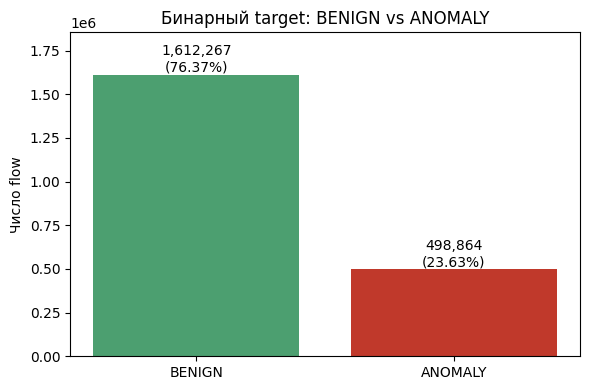

In [27]:
# 1. Бинарный target
fig, ax = plt.subplots(figsize=(6, 4))
counts = pd.Series({"BENIGN": n_benign, "ANOMALY": n_anom})
ax.bar(counts.index, counts.values, color=["#4C9F70", "#C0392B"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({100*v/n_total:.2f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Число flow")
ax.set_title("Бинарный target: BENIGN vs ANOMALY")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_target_binary.png", dpi=150)
plt.show()

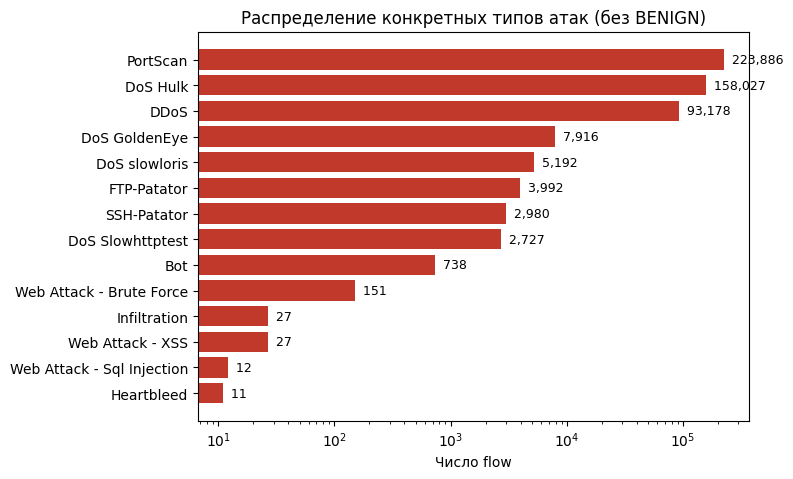

In [29]:
# 2. Распределение типов атак (без BENIGN), горизонтальный bar
attack_only = label_counts.drop(BENIGN_LABEL, errors="ignore").sort_values()
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(attack_only))))
ax.barh(attack_only.index.astype(str), attack_only.values, color="#C0392B")
for i, v in enumerate(attack_only.values):
    ax.text(v, i, f"  {v:,}", va="center", fontsize=9)
ax.set_xlabel("Число flow")
ax.set_title("Распределение конкретных типов атак (без BENIGN)")
ax.set_xscale("log")  # log !!!
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_attack_types.png", dpi=150)
plt.show()

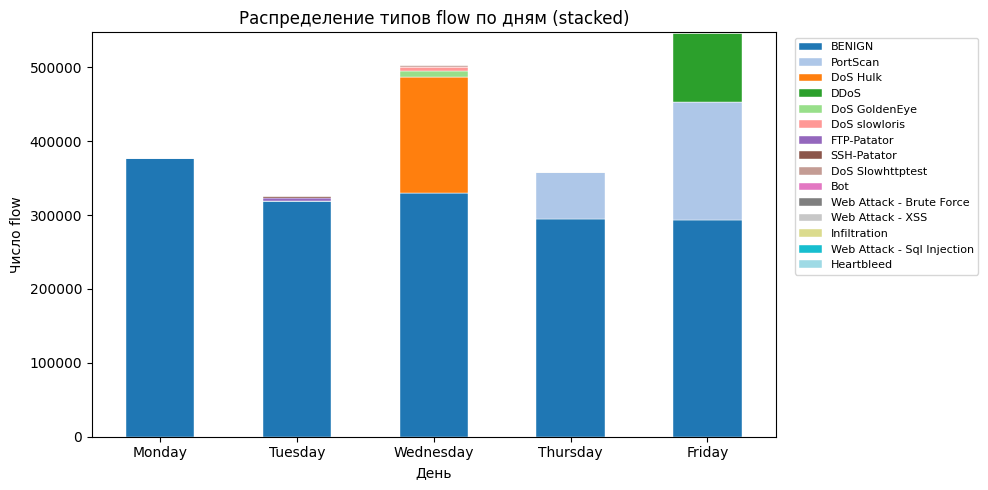

In [30]:
# 3. Stacked bar: какие типы атак в какой день
plot_df = attack_by_day.drop(columns="__total").T # переделать
plot_df = plot_df.loc[:, plot_df.sum(axis=0) > 0]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind="bar", stacked=True, ax=ax, colormap="tab20",
             edgecolor="white", linewidth=0.3)
ax.set_xlabel("День")
ax.set_ylabel("Число flow")
ax.set_title("Распределение типов flow по дням (stacked)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_label_per_day_stacked.png", dpi=150,
            bbox_inches="tight")
plt.show()


## 10. Top-10 колонок по размаху, разреженности

**Вычисляются**:
- **Размах** = `max − min` по числовой колонке. Большие размахи -> тяжёлые хвосты,
  нужен log1p для визуализации.
- **Разреженность** = доля строк, где значение `0`.
- **NaN** — уже посчитано ранее, top-10 здесь.

In [31]:
# Top-10 по размаху
rng = (desc_rounded["max"] - desc_rounded["min"]).sort_values(ascending=False)
top_range = rng.head(10).to_frame("range").join(
    desc_rounded[["min", "max", "mean", "std"]]
)
print("=== Top-10 по размаху (max - min) ===")
print(top_range.to_string())


=== Top-10 по размаху (max - min) ===
                                    range           min           max          mean           std
dst2src_last_seen_ms         1.499458e+12  0.000000e+00  1.499458e+12  1.463192e+12  2.298059e+11
dst2src_first_seen_ms        1.499458e+12  0.000000e+00  1.499458e+12  1.463192e+12  2.298059e+11
bidirectional_bytes          6.844843e+08  6.000000e+01  6.844843e+08  2.378462e+04  2.735240e+06
dst2src_bytes                6.712093e+08  0.000000e+00  6.712093e+08  1.617758e+04  1.913592e+06
src2dst_bytes                6.552848e+08  6.000000e+01  6.552849e+08  7.607033e+03  1.880804e+06
bidirectional_last_seen_ms   3.747635e+08  1.499083e+12  1.499458e+12  1.499286e+12  1.256697e+08
src2dst_first_seen_ms        3.747634e+08  1.499083e+12  1.499458e+12  1.499286e+12  1.256712e+08
bidirectional_first_seen_ms  3.747634e+08  1.499083e+12  1.499458e+12  1.499286e+12  1.256712e+08
src2dst_last_seen_ms         3.747634e+08  1.499083e+12  1.499458e+12  1.499286e

In [32]:
# Top-10 по разреженности (доля нулей)
sparsity_rows = []
for c in numeric_cols_all:
    if c in ("target",):
        continue
    s = df_all[c]
    n_zero = int((s == 0).sum())
    sparsity_rows.append({
        "column": c,
        "pct_zero": round(100 * n_zero / len(s), 3),
        "n_zero":   n_zero,
    })
sparsity = pd.DataFrame(sparsity_rows).sort_values("pct_zero", ascending=False)
print("=== Top-10 по разреженности (доля нулей) ===")
print(sparsity.head(10).to_string(index=False))

=== Top-10 по разреженности (доля нулей) ===
                   column  pct_zero  n_zero
      dst2src_urg_packets   100.000 2111130
                  vlan_id   100.000 2111131
      dst2src_cwr_packets    99.999 2111114
bidirectional_urg_packets    99.996 2111037
      src2dst_urg_packets    99.996 2111038
      dst2src_ece_packets    99.972 2110548
bidirectional_ece_packets    99.968 2110445
      src2dst_ece_packets    99.968 2110445
bidirectional_cwr_packets    99.964 2110367
      src2dst_cwr_packets    99.964 2110381


In [33]:
# Top-10 по NaN (если есть)
top_nan = health.sort_values("n_nan", ascending=False).head(10)
if top_nan["n_nan"].sum() == 0:
    print("=== NaN в датасете отсутствуют ===")
else:
    print("=== Top-10 по NaN ===")
    print(top_nan[["column", "n_nan", "pct_nan", "n_inf"]].to_string(index=False))


=== NaN в датасете отсутствуют ===


# Итоги исследования

1. **Объём.** Всего `2,111,131` flow по 5 дням. `Friday.csv` — самый крупный,
   `Monday` — только `BENIGN`.

2. **Баланс классов.** Доля ANOMALY ≈ `X%`. Дисбаланс умеренный — supervised
   модели справятся без oversampling, но class weighting (`pos_weight` для MLP)
   всё равно включаем по плану.

3. **Привязка атак к дням.** Tuesday — Brute Force (FTP/SSH-Patator),
   Wednesday — DoS (Hulk, GoldenEye, slowloris, Slowhttptest), Thursday — Web
   Attack / Infiltration, Friday — PortScan / Bot / DDoS. Совпадает с описанием
   CICIDS-2017.

4. **Проблемы данных.** NaN/Inf: `0`. Отрицательные `0`.

5. **Тяжёлые хвосты.** Колонки `*_bytes`, `*_piat_ms`, `*_duration_ms` имеют
   размах на много порядков.